In [2]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import torch
import random
import transformers
from transformers import BertModel
from transformers import BertTokenizer
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
import time

seed_value=42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)

In [3]:
FILE_PATH = '../../all_datasets_transformers.csv'
df = pd.read_csv(FILE_PATH)
df = df.drop_duplicates()
df = df.dropna(how='any')
df.head()

,text,type,label
0,"USER Because while other groups can evolve, th...",cyberbullying,1
1,New Discussion While I understand your poin...,not_cyberbullying,0
2,No page was reviewed by Tentinator This rec...,not_cyberbullying,0
3,Laughing big grin or laugh with glasses...,not_cyberbullying,0
4,USER you should not have taken the statue away...,cyberbullying,1


In [10]:
df['text_len'] = [len(text.split()) for text in df['text']]
df.sort_values(by=['text_len'], ascending=False)

,text,type,label,text_len
141023,Reply to your request for help I have read ...,not_cyberbullying,0,728
18614,Sweden The legal actions taken by the Swedish...,not_cyberbullying,0,728
14988,"Matthew Bevan Cox, commonly known as Matthew C...",not_cyberbullying,0,728
58752,INCONSISTENCIES On the two narratives of th...,not_cyberbullying,0,728
41596,You stupid nigger You stupid nigger You stu...,cyberbullying,1,728
...,...,...,...,...
110130,: October,not_cyberbullying,0,2
86562,gt;go south,cyberbullying,1,2
139032,sooooooo luckyyyyy!!!!!!!,cyberbullying,1,2
86574,USER YUP.,not_cyberbullying,0,2


In [5]:
df = df[df['text_len'] < df['text_len'].quantile(0.995)]
max_len = np.max(df['text_len'])
max_len

728

In [9]:
df.sort_values(by=["text_len"], ascending=False)

,text,type,label,text_len
141023,Reply to your request for help I have read ...,not_cyberbullying,0,728
18614,Sweden The legal actions taken by the Swedish...,not_cyberbullying,0,728
14988,"Matthew Bevan Cox, commonly known as Matthew C...",not_cyberbullying,0,728
58752,INCONSISTENCIES On the two narratives of th...,not_cyberbullying,0,728
41596,You stupid nigger You stupid nigger You stu...,cyberbullying,1,728
...,...,...,...,...
110130,: October,not_cyberbullying,0,2
86562,gt;go south,cyberbullying,1,2
139032,sooooooo luckyyyyy!!!!!!!,cyberbullying,1,2
86574,USER YUP.,not_cyberbullying,0,2


In [8]:
df = df[df["text_len"] != 1]

In [11]:
X = df['text'].values
y = df['label'].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed_value)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=seed_value)

In [13]:
print("Train distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("Test distribution:\n", pd.Series(y_test).value_counts(normalize=True))
print("Valid distribution:\n", pd.Series(y_valid).value_counts(normalize=True))

Train distribution:
 0    0.559482
1    0.440518
Name: proportion, dtype: float64
Test distribution:
 0    0.559494
1    0.440506
Name: proportion, dtype: float64
Valid distribution:
 0    0.559465
1    0.440535
Name: proportion, dtype: float64


In [14]:
label_to_type = df.drop_duplicates(subset=['label']) \
                       .set_index('label')['type'].to_dict()

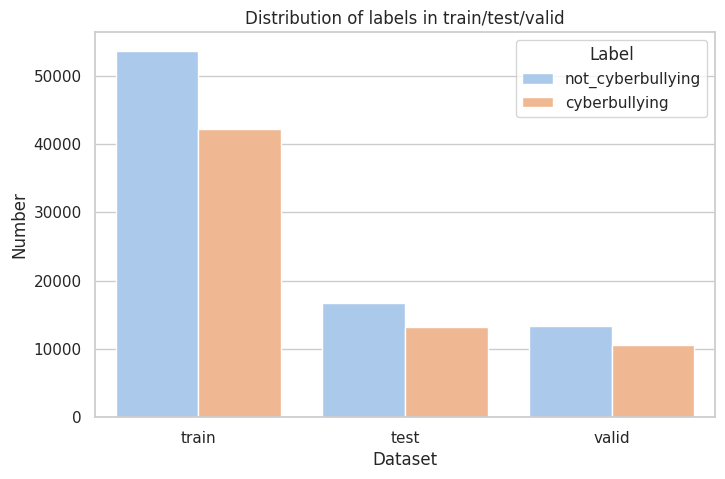

In [15]:
df_dist = pd.DataFrame({
    'dataset': ['train'] * len(y_train) + ['test'] * len(y_test) + ['valid'] * len(y_valid),
    'label':  list(y_train) + list(y_test) + list(y_valid)
})
df_dist['type'] = df_dist['label'].map(label_to_type)

sns.set(style='whitegrid')

plt.figure(figsize=(8, 5))
sns.countplot(data=df_dist, x='dataset', hue='type',palette='pastel')
plt.title('Distribution of labels in train/test/valid')
plt.xlabel('Dataset')
plt.ylabel('Number')
plt.legend(title='Label')
plt.show()

In [16]:
ros = RandomOverSampler()

X_train_os, y_train_os = ros.fit_resample(
    np.array(X_train).reshape(-1, 1),
    np.array(y_train).ravel()  
)

X_train_os = X_train_os.flatten() 
y_train_os = y_train_os.flatten()

In [17]:
(unique, counts) = np.unique(y_train_os, return_counts=True)
np.asarray((unique, counts)).T

array([[    0, 53684],
       [    1, 53684]])

In [18]:
tokenizer = BertTokenizer.from_pretrained('GroNLP/hateBERT')

In [22]:
MAX_LEN = 512

In [23]:
def bert_tokenizer(data):
    input_ids = []
    attention_masks = []
    for sent in data:
        encoded_sent = tokenizer.encode_plus(
            text=sent,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',     
            truncation=True,         
            return_attention_mask=True
        )
        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))

    input_ids = torch.tensor(input_ids)
    attention_masks = torch.tensor(attention_masks)

    return input_ids, attention_masks

In [24]:
encoded_tweets = [tokenizer.encode(sent, add_special_tokens=True) for sent in X_train]

max_len = max([len(sent) for sent in encoded_tweets])
print('Max length: ', max_len)

Max length:  9855


In [ ]:
train_inputs, train_masks = bert_tokenizer(X_train_os)
val_inputs, val_masks = bert_tokenizer(X_valid)
test_inputs, test_masks = bert_tokenizer(X_test)

In [19]:
train_labels = torch.from_numpy(y_train_os)
val_labels = torch.from_numpy(y_valid)
test_labels = torch.from_numpy(y_test)

In [20]:
print(train_inputs.shape, train_labels.shape)
print(val_inputs.shape, val_labels.shape)

torch.Size([25485, 256]) torch.Size([25485])
torch.Size([6287, 256]) torch.Size([6287])


In [21]:
batch_size = 32

In [22]:
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

In [23]:
val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

In [24]:
test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

In [26]:
class Bert_Classifier(nn.Module):
    def __init__(self, freeze_bert=False):
        super(Bert_Classifier, self).__init__()

        n_input  = 768
        n_hidden = 384   
        n_mid    = 50
        n_output = 5
      
        self.bert = BertModel.from_pretrained('GroNLP/hateBERT')

        self.classifier = nn.Sequential(
            nn.Linear(n_input,  n_hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_hidden, n_mid),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_mid,    n_output)
        )
    
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_emb = outputs.last_hidden_state[:, 0, :]
        logits  = self.classifier(cls_emb)
        return logits

In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS=3

In [28]:
def initialize_model(epochs=4):
    model = Bert_Classifier(freeze_bert=False).to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=5e-5,        # înjumătăţit faţă de 5e-5
        eps=1e-8,
        weight_decay=0.01
    )

    total_steps = len(train_dataloader) * epochs
    warmup_steps = int(0.1 * total_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    return model, optimizer, scheduler

In [29]:
bert_classifier, optimizer, scheduler = initialize_model(epochs=EPOCHS)

Some weights of the model checkpoint at GroNLP/hateBERT were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [30]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def train(model,
          train_dataloader,
          optimizer,
          scheduler,
          val_dataloader=None,
          epochs=4,
          evaluation=False):

    history = {
        'loss': [], 
        'accuracy': [],
        'val_loss': [], 
        'val_accuracy': []
    }

    print("Start training...\n")
    for epoch in range(1, epochs+1):
        # ─── Header Epocă ───
        print("-"*10)
        print(f"Epoch : {epoch}")
        print("-"*10)
        print("-"*38)
        print(f"{'BATCH NO.':^9} | {'TRAIN LOSS':^12} | {'ELAPSED (s)':^9}")
        print("-"*38)

        t0_epoch, t0_batch = time.time(), time.time()
        total_loss, batch_loss, batch_count = 0, 0, 0
        total_acc = 0

        model.train()
        for step, batch in enumerate(train_dataloader, 1):
            batch_count += 1
            b_ids, b_mask, b_labels = [t.to(device) for t in batch]

            optimizer.zero_grad()
            logits = model(b_ids, b_mask)
            loss   = loss_fn(logits, b_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            batch_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            total_acc += (preds == b_labels).float().mean().item()

            # ─── Print batch ───
            if step % 100 == 0 or step == len(train_dataloader):
                t_batch = time.time() - t0_batch
                print(f"{step:^9} | {batch_loss/batch_count:^12.6f} | {t_batch:^9.2f}")
                batch_loss, batch_count = 0, 0
                t0_batch = time.time()

        # ─── Statistici training ───
        avg_train_loss = total_loss / len(train_dataloader)
        avg_train_acc  = (total_acc / len(train_dataloader)) * 100
        history['loss'].append(avg_train_loss)
        history['accuracy'].append(avg_train_acc)

        # ─── Evaluare ───
        if evaluation and val_dataloader is not None:
            model.eval()
            val_loss_sum, val_acc_sum = 0, 0

            with torch.no_grad():
                for batch in val_dataloader:
                    v_ids, v_mask, v_labels = [t.to(device) for t in batch]
                    logits = model(v_ids, v_mask)
                    val_loss_sum += loss_fn(logits, v_labels).item()
                    preds = torch.argmax(logits, dim=1)
                    val_acc_sum += (preds == v_labels).float().mean().item()

            avg_val_loss = val_loss_sum / len(val_dataloader)
            avg_val_acc  = (val_acc_sum  / len(val_dataloader)) * 100
            history['val_loss'].append(avg_val_loss)
            history['val_accuracy'].append(avg_val_acc)

            t_epoch = time.time() - t0_epoch
            # ─── Print tabel epoch ───
            print("-"*61)
            print(f"{'AVG TRAIN LOSS':^14} | {'TRAIN ACC (%)':^14} | {'VAL LOSS':^10} | {'VAL ACC (%)':^10} | {'TIME (s)':^9}")
            print("-"*61)
            print(f"{avg_train_loss:^14.6f} | {avg_train_acc:^14.2f} | {avg_val_loss:^10.6f} | {avg_val_acc:^10.2f} | {t_epoch:^9.2f}")
            print("-"*61 + "\n")
        else:
            t_epoch = time.time() - t0_epoch
            print(f"Epoch {epoch} completed in {t_epoch:.2f}s — train_loss: {avg_train_loss:.4f}, train_acc: {avg_train_acc:.2f}%\n")

    print("Training complete!\n")
    return history


In [31]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
bert_classifier.to(device)

history = train(
    model=bert_classifier,
    train_dataloader=train_dataloader,
    optimizer=optimizer,          
    scheduler=scheduler,        
    val_dataloader=val_dataloader,
    epochs=EPOCHS,
    evaluation=True
)

Start training...

----------
Epoch : 1
----------
--------------------------------------
BATCH NO. |  TRAIN LOSS  | ELAPSED (s)
--------------------------------------
   100    |   1.550310   |   32.42  
   200    |   0.924870   |   31.94  
   300    |   0.608317   |   31.97  
   400    |   0.566990   |   31.99  
   500    |   0.543468   |   32.01  
   600    |   0.523158   |   32.00  
   700    |   0.527977   |   32.01  
   797    |   0.524696   |   30.82  
-------------------------------------------------------------
AVG TRAIN LOSS | TRAIN ACC (%)  |  VAL LOSS  | VAL ACC (%) | TIME (s) 
-------------------------------------------------------------
   0.721963    |     86.26      |  0.495311  |   95.35    |  276.58  
-------------------------------------------------------------

----------
Epoch : 2
----------
--------------------------------------
BATCH NO. |  TRAIN LOSS  | ELAPSED (s)
--------------------------------------
   100    |   0.508166   |   32.01  
   200    |   0.496631

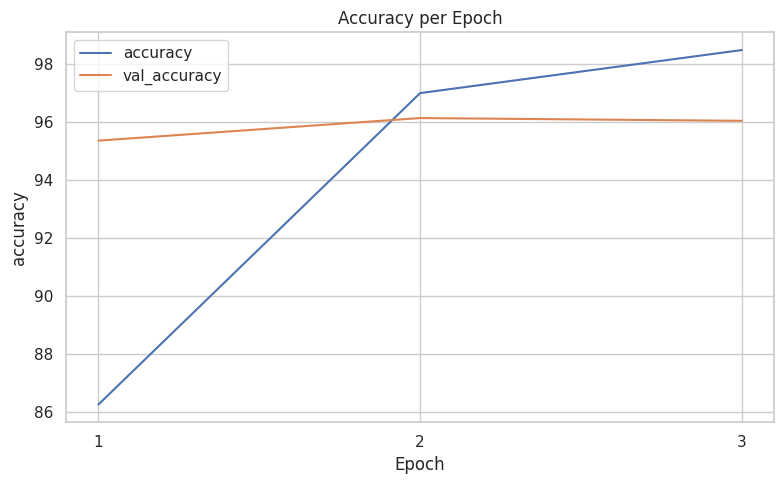

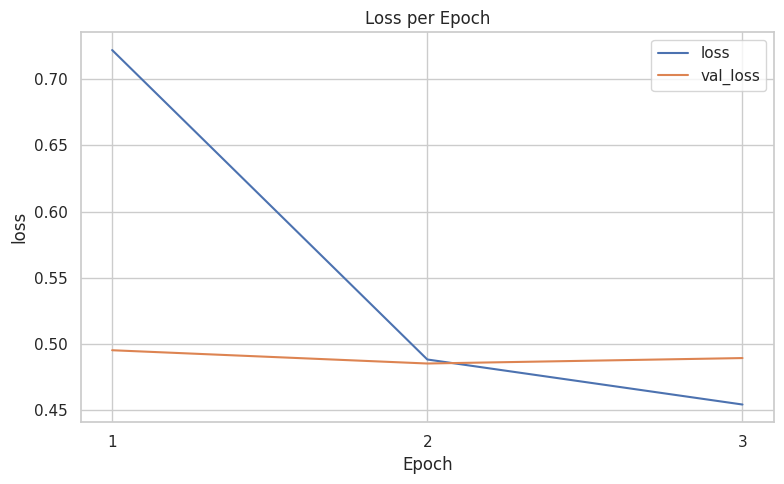

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_graphs(history, metric):
    epochs = np.arange(1, len(history[metric]) + 1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs,
             history[metric],
             label=metric)
    plt.plot(epochs,
             history['val_' + metric],
             label='val_' + metric)
    plt.title(f'{metric.capitalize()} per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [34]:
def bert_predict(model, test_dataloader):
    
    preds_list = []
    
    model.eval()
    
    for batch in test_dataloader:
        batch_input_ids, batch_attention_mask = tuple(t.to(device) for t in batch)[:2]
        
        with torch.no_grad():
            logit = model(batch_input_ids, batch_attention_mask)
        
        pred = torch.argmax(logit,dim=1).cpu().numpy()
        
        preds_list.extend(pred)

    return preds_list

In [ ]:
bert_preds = bert_predict(bert_classifier, test_dataloader)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
sentiments = ["religion","age","ethnicity","gender","other_cyberbullying"]

In [ ]:
print('Classification Report for BERT :\n', classification_report(y_test, bert_preds, target_names=sentiments))

In [ ]:
report = classification_report(y_test, bert_preds, output_dict=True)

# Plotting the classification report
fig, ax = plt.subplots(figsize=(12, 6))

# Categories for the classification
categories = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', and 'weighted avg'

# Extracting precision, recall, and f1-score
precision = [report[category]['precision'] for category in categories]
recall = [report[category]['recall'] for category in categories]
f1_score = [report[category]['f1-score'] for category in categories]

# Setting the positions and width for the bars
pos = list(range(len(categories)))
width = 0.25 

# Plotting each metric
plt.bar(pos, precision, width, alpha=0.5, color='#ff33cc', label='Precision')
plt.bar([p + width for p in pos], recall, width, alpha=0.5, color='#6600ff', label='Recall')
plt.bar([p + width*2 for p in pos], f1_score, width, alpha=0.5, color='#00cc99', label='F1-Score')

# Adding the aesthetics
plt.xlabel('Category')
plt.ylabel('Score')
plt.title('Classification Report')
plt.xticks([p + width for p in pos], ['religion',
    'age',
    'ethnicity',
    'gender',
    'other_cyberbullying'])

# Adding the legend and showing the plot
plt.legend(['Precision', 'Recall', 'F1-Score'], loc='upper left')
plt.grid()
plt.show()

In [ ]:
def conf_matrix(y, y_pred, title, labels):
    fig, ax =plt.subplots(figsize=(7.5,7.5))
    ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Purples", fmt='g', cbar=False, annot_kws={"size":30})
    plt.title(title, fontsize=25)
    ax.xaxis.set_ticklabels(labels, fontsize=16) 
    ax.yaxis.set_ticklabels(labels, fontsize=14.5)
    ax.set_ylabel('Test', fontsize=25)
    ax.set_xlabel('Predicted', fontsize=25)
    plt.show()

In [ ]:
conf_matrix(y_test, bert_preds,' BERT Sentiment Analysis\nConfusion Matrix', sentiments)

In [ ]:
torch.save(bert_classifier.state_dict(), "cyberbullying_bert_model.pth")